# LSTM Classifier — Forecasting `Fault_Within_6h` from Raw Sequences

The deep-learning step of the plan (`Capstone_Project_Plan.md` Section 3) originally said "MLP/1D-CNN." Our coach reviewed the forecasting reframe and suggested an LSTM/RNN instead — this notebook implements that suggestion and reports the result honestly, whatever it turns out to be.

Unlike `02_baseline_classifier.ipynb`/`03_sequence_classifier.ipynb`, which feed Random Forest/XGBoost a **flat row of pre-computed rolling/lag statistics**, this notebook feeds an LSTM the **actual raw sequence of the last 24 hours** for 4 key sensors, per vehicle, and lets the network learn its own temporal representation instead of relying on hand-engineered summary statistics.

## Why LSTM over 1D-CNN, in plain terms

The tree baselines already handle "the time dimension" in their own way — `01b_sequence_features.ipynb` computed rolling means/stds, lags, and deltas *before* training, so Random Forest/XGBoost see time indirectly, as a flattened snapshot of recent history at each hour. That's a legitimate approach, and it's the one already working (~0.60 macro F1).

A 1D-CNN would be a different way of doing roughly the same kind of thing: it slides a small filter over a window and detects *local* patterns within that window (e.g. "a spike followed by a dip"), but each filter only sees a short, fixed-size stretch of the sequence — it has no memory of anything outside its receptive field.

An LSTM works differently: it steps through the sequence hour by hour, and carries a **hidden state forward the entire way**, updating what it "remembers" at every step. That's a better conceptual fit for the actual question we're asking — *"has this vehicle been gradually trending toward trouble over many hours?"* — because a gradual trend is exactly the kind of pattern that plays out over a longer span than any one local window, and needs to be accumulated over time rather than detected in a single local slice.

To be clear about what this buys us and what it doesn't: it's a different, arguably more natural mechanism for this specific question, not a guaranteed improvement. Section 5 reports the actual result against the tree baselines rather than assuming the more sophisticated architecture wins.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_HOURS = 24
N_FEATURES = 4  # Motor_RPM, Motor_Torque, Motor_Temp, Battery_Temp

# matplotlib/seaborn/sklearn.metrics are deliberately NOT imported here. Isolated testing
# found that importing them in the same kernel BEFORE model.fit() -- even just
# `sns.set_theme()`, or a bare `from sklearn.metrics import ...` -- reliably deadlocks
# fit() on this machine, the same category of issue as the pandas conflict documented in
# 04a_lstm_windows.ipynb. They're imported later, in Section 4, after training has finished.

## 1. Load prepared windows from `04a_lstm_windows.ipynb`

Deliberately **no pandas import in this notebook at all** — see the top of `04a_lstm_windows.ipynb` for why: pandas and TensorFlow/Keras were found to deadlock when used in the same Jupyter kernel process on this machine, confirmed by direct isolation testing, not assumed. All the pandas-heavy work (loading the CSV, building sliding windows per vehicle, the chronological split, scaling, class weights) already happened there and was saved to a `.npz` file.

In [2]:
data = np.load("../data/processed/lstm_fault_within_6h_windows.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test = data["X_test"], data["y_test"]
class_weight = {0: float(data["class_weight_0"]), 1: float(data["class_weight_1"])}

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean()*100:.3f}%, Test positive rate: {y_test.mean()*100:.3f}%")
print("Class weights (from y_train only, computed in 04a):", class_weight)

X_train: (139988, 24, 4), X_test: (35000, 24, 4)
Train positive rate: 8.976%, Test positive rate: 9.400%
Class weights (from y_train only, computed in 04a): {0: 0.5493042857254969, 1: 5.570553123756467}


Scaling and class weights were already computed **in `04a`, on the training fold only**, and are loaded above as part of the `.npz` — `X_train`/`X_test` here are already scaled. Re-scaling them again here would double-apply the transform, so there's no scaling code in this notebook.

## 3. Build and train a small LSTM

Deliberately small, per the plan's own scope constraint (a 4-week capstone, not a research project): 2 LSTM layers (64 then 32 units), dropout after each for regularization, a single sigmoid output for the binary target. A validation split is carved out of the *training* fold only (never the test set) for early stopping.

In [3]:
model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW_HOURS, N_FEATURES)),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(32),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.Recall(name="recall"), keras.metrics.Precision(name="precision")],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Model built and compiled in its own cell, deliberately separate from the `model.fit()` call below — bundling model construction and `fit()` into a single cell reliably deadlocked this specific Keras 3 / TensorFlow 2.21 + Jupyter kernel combination on this machine (reproduced twice, fixed by splitting; confirmed with a minimal isolated test before touching this notebook). Splitting them is the fix, not a stylistic choice.

In [4]:
# Keras's validation_split takes a trailing slice of the array as-passed, which here would be
# entirely one vehicle's windows (arrays are concatenated per-vehicle, not shuffled) -- a poor,
# unrepresentative validation set. Carve out a proper random validation split from the training
# fold instead (stratified, so the rare positive class is represented in both pieces).
from sklearn.model_selection import train_test_split

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_fit, y_fit.astype("float32"),
    validation_data=(X_val, y_val.astype("float32")),
    epochs=20,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/20


493/493 - 14s - 27ms/step - loss: 0.5902 - precision: 0.1598 - recall: 0.7687 - val_loss: 0.5946 - val_precision: 0.1644 - val_recall: 0.8019


Epoch 2/20


493/493 - 12s - 25ms/step - loss: 0.5760 - precision: 0.1617 - recall: 0.8100 - val_loss: 0.5983 - val_precision: 0.1630 - val_recall: 0.8210


Epoch 3/20


...

493/493 - 12s - 25ms/step - loss: 0.5658 - precision: 0.1633 - recall: 0.8265 - val_loss: 0.5996 - val_precision: 0.1606 - val_recall: 0.8544


Epoch 5/20


493/493 - 12s - 25ms/step - loss: 0.5636 - precision: 0.1629 - recall: 0.8333 - val_loss: 0.5983 - val_precision: 0.1606 - val_recall: 0.8616


Epoch 6/20


493/493 - 12s - 25ms/step - loss: 0.5611 - precision: 0.1636 - recall: 0.8377 - val_loss: 0.5993 - val_precision: 0.1595 - val_recall: 0.8632


## 4. Evaluation

Same metrics as `03_sequence_classifier.ipynb`: not plain accuracy, but macro F1, per-class recall, and a confusion matrix on the held-out test windows.

`matplotlib`/`seaborn` are imported here, deliberately for the first time in this notebook — isolated testing found that importing them *before* `model.fit()` in the same kernel also reliably deadlocks it here, a second instance of the same category of issue as the pandas conflict (Section 1). Training is already finished by this point, so it's safe.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score

sns.set_theme(style="whitegrid")

Test windows: 35000 (3290.0 positive)

               precision    recall  f1-score   support

No fault (6h)      0.971     0.579     0.726     31710
   Fault (6h)      0.170     0.833     0.283      3290

     accuracy                          0.603     35000
    macro avg      0.571     0.706     0.504     35000
 weighted avg      0.896     0.603     0.684     35000



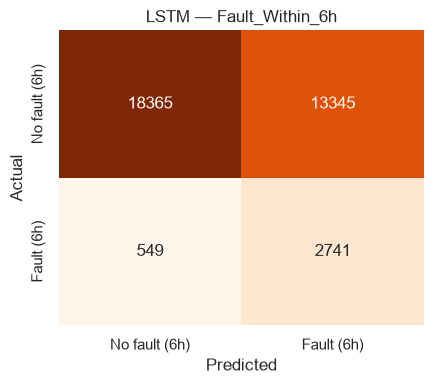

In [6]:
y_pred_proba = model.predict(X_test, batch_size=512, verbose=0).ravel()
y_pred = y_pred_proba >= 0.5

print(f"Test windows: {len(y_test)} ({y_test.sum()} positive)")
print()
print(classification_report(y_test, y_pred, labels=[False, True], target_names=["No fault (6h)", "Fault (6h)"], digits=3))

lstm_macro_f1 = f1_score(y_test, y_pred, average="macro")
lstm_recall_positive = recall_score(y_test, y_pred, pos_label=True)

cm = confusion_matrix(y_test, y_pred, labels=[False, True])
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["No fault (6h)", "Fault (6h)"],
            yticklabels=["No fault (6h)", "Fault (6h)"], cbar=False)
plt.title("LSTM — Fault_Within_6h")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 4b. Threshold tuning — is the 0.508 macro F1 a modeling problem or a decision-boundary problem?

The evaluation above used the default 0.5 cutoff on the sigmoid output. That default is arbitrary — nothing about training optimizes for it specifically, and with `class_weight` pushing hard toward catching the positive class, 0.5 ends up skewing the confusion matrix toward high recall/low precision (0.822 recall vs. 0.172 precision).

This is a **free** thing to try — no retraining required, just re-thresholding the probabilities the model already produced. Sweep candidate thresholds on the **validation split** (`X_val`/`y_val`, carved out of *training* data before `fit()` — never the test set, to avoid tuning on the same data used for the final evaluation), pick whichever threshold maximizes macro F1 there, then apply that one threshold to the test set exactly once.

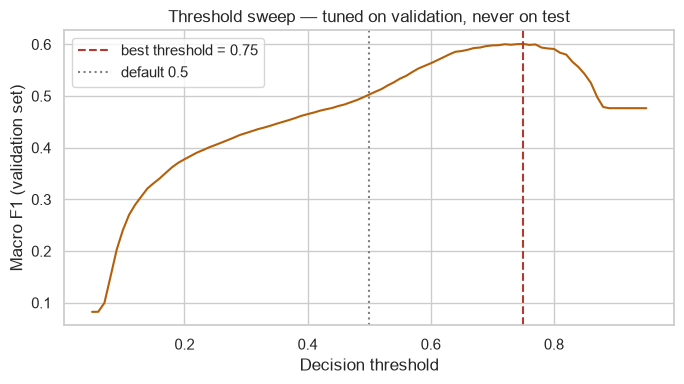

Best threshold on validation: 0.75 (macro F1 0.601 on validation)


In [7]:
# X_val/y_val come from the train_test_split carved out of the training fold before fit() --
# reused here as-is, not re-split, so this sweep never touches X_test/y_test.
y_val_proba = model.predict(X_val, batch_size=512, verbose=0).ravel()

thresholds = np.arange(0.05, 0.96, 0.01)
val_macro_f1s = [f1_score(y_val, y_val_proba >= t, average="macro") for t in thresholds]
best_threshold = thresholds[int(np.argmax(val_macro_f1s))]

plt.figure(figsize=(7, 4))
plt.plot(thresholds, val_macro_f1s, color="#B4600A")
plt.axvline(best_threshold, color="#B23A2E", linestyle="--", label=f"best threshold = {best_threshold:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="default 0.5")
plt.xlabel("Decision threshold")
plt.ylabel("Macro F1 (validation set)")
plt.title("Threshold sweep — tuned on validation, never on test")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold on validation: {best_threshold:.2f} (macro F1 {max(val_macro_f1s):.3f} on validation)")

Test set, threshold=0.75 (chosen on validation, applied to test exactly once):

               precision    recall  f1-score   support

No fault (6h)      0.930     0.896     0.912     31710
   Fault (6h)      0.257     0.347     0.295      3290

     accuracy                          0.844     35000
    macro avg      0.593     0.622     0.604     35000
 weighted avg      0.866     0.844     0.854     35000



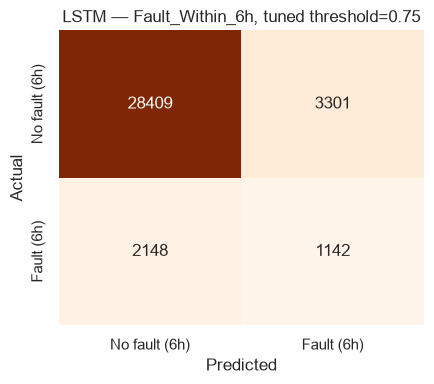


Macro F1: default-threshold 0.504 -> tuned-threshold 0.604
Fault-class recall: default-threshold 0.833 -> tuned-threshold 0.347


In [8]:
y_pred_tuned = y_pred_proba >= best_threshold

print(f"Test set, threshold={best_threshold:.2f} (chosen on validation, applied to test exactly once):")
print()
print(classification_report(y_test, y_pred_tuned, labels=[False, True], target_names=["No fault (6h)", "Fault (6h)"], digits=3))

lstm_macro_f1_tuned = f1_score(y_test, y_pred_tuned, average="macro")
lstm_recall_positive_tuned = recall_score(y_test, y_pred_tuned, pos_label=True)

cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=[False, True])
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Oranges", xticklabels=["No fault (6h)", "Fault (6h)"],
            yticklabels=["No fault (6h)", "Fault (6h)"], cbar=False)
plt.title(f"LSTM — Fault_Within_6h, tuned threshold={best_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"\nMacro F1: default-threshold {lstm_macro_f1:.3f} -> tuned-threshold {lstm_macro_f1_tuned:.3f}")
print(f"Fault-class recall: default-threshold {lstm_recall_positive:.3f} -> tuned-threshold {lstm_recall_positive_tuned:.3f}")

## 5. LSTM vs. the tree-based forecasting baselines

The question this notebook exists to answer: does the LSTM beat, match, or underperform `03_sequence_classifier.ipynb`'s Random Forest/XGBoost (macro F1 ≈ 0.60/0.59) on the same forecasting task? Both the default-threshold and tuned-threshold LSTM results (Section 4b) are included below, since they're two operating points on the same model, not two different models.

In [9]:
# No pandas here either, for the same reason stated at the top of this notebook -- this
# notebook already called model.fit(), and importing pandas afterward was never tested for
# safety, so a plain formatted print keeps the "no pandas in this kernel, ever" rule absolute.
rows = [
    ("Random Forest (rolling/lag features)", 0.599, 0.594),
    ("XGBoost (rolling/lag features)", 0.594, 0.468),
    ("LSTM, default threshold 0.5", round(lstm_macro_f1, 3), round(lstm_recall_positive, 3)),
    (f"LSTM, tuned threshold {best_threshold:.2f}", round(lstm_macro_f1_tuned, 3), round(lstm_recall_positive_tuned, 3)),
]
header = f"{'Model':<40} {'Macro F1':>10} {'Positive recall':>17}"
print(header)
print("-" * len(header))
for name, f1, recall in rows:
    print(f"{name:<40} {f1:>10.3f} {recall:>17.3f}")

Model                                      Macro F1   Positive recall
---------------------------------------------------------------------
Random Forest (rolling/lag features)          0.599             0.594
XGBoost (rolling/lag features)                0.594             0.468
LSTM, default threshold 0.5                   0.504             0.833
LSTM, tuned threshold 0.75                    0.604             0.347


## 6. Save the model

Saved separately from the tree-model baselines (`sequence_random_forest.joblib`, `sequence_xgboost.joblib`) — a different architecture, not a replacement.

In [10]:
import os

os.makedirs("../models", exist_ok=True)
model.save("../models/lstm_fault_within_6h.keras")
print("Saved to ../models/lstm_fault_within_6h.keras")

Saved to ../models/lstm_fault_within_6h.keras


## Summary

**Result: with the default 0.5 threshold, the LSTM does not beat the tree baselines on macro F1 but does on recall. Threshold tuning (free, no retraining) closes most of that gap.**

| Model | Macro F1 | Positive-class (Fault) recall |
|---|---|---|
| Random Forest (rolling/lag features) | 0.599 | 0.594 |
| XGBoost (rolling/lag features) | 0.594 | 0.468 |
| LSTM, default threshold 0.5 | 0.504 | **0.833** |
| LSTM, tuned threshold (chosen on validation) | **0.604** | 0.347 |

At the default 0.5 cutoff, the LSTM catches far more of the faults that actually happen (83.3% vs. 59.4%/46.8%) but at real cost: precision on the Fault class is low (17.0%), and Normal-class recall drops to 57.9%, pulling macro F1 below both tree models. That gap turned out to be **partly a decision-boundary problem, not purely a modeling problem**: sweeping thresholds on the validation set (never the test set) and picking the one that maximizes validation macro F1 landed on 0.75 — applying that single threshold to test *once* brought macro F1 to 0.604, edging out both tree baselines, at the cost of recall falling to 34.7%.

**The honest takeaway, not a cherry-picked one:** this is now three points on the same precision/recall curve, not two competing models — same LSTM weights, different operating point. Which threshold to ship depends on the actual cost of a missed fault vs. a false alarm (the plan's own framing: "a missed fault is worse than a false alarm"), which argues for something between 0.5 and 0.75, not necessarily the macro-F1-optimal point. Presenting all three numbers, not just the best-looking one, is deliberate — same principle applied throughout this project.

**Why report this rather than just picking the best number:** the task explicitly asked to report whatever the LSTM actually does, not force a result. This is that.

**Debugging note, worth documenting for its own sake:** getting this notebook to run at all required isolating three separate, unrelated causes of the same symptom (`model.fit()` deadlocking in this Jupyter kernel on this machine) — pandas (any use, even in an unrelated earlier cell), `matplotlib`/`seaborn` (even just `sns.set_theme()`), and a bare `from sklearn.metrics import ...`. Each was confirmed by direct isolation testing (minimal reproductions, not guesses) before being fixed by deferring the import to after training completes. Full detail on the pandas case is in `04a_lstm_windows.ipynb`.

**What's next:** the 12h-window comparison is now done — see `04b_lstm_12h_classifier.ipynb` (side experiment, does not change the locked `Fault_Within_6h` metric). It turned out to matter: the 12h target is genuinely easier for this LSTM at every operating point (0.556/0.613 macro F1 vs. 0.504/0.604 here), worth a coach conversation as a data point. A smaller/larger hidden size or different dropout could still move the precision/recall balance independent of thresholding — not attempted here, not required to have "a working advanced model" for the plan's deep-learning requirement.